# Notebook 01 ,  Datos: obtención, validación y limpieza

Big Data and Machine Learning para Economía Aplicada (MECA 4107, 2026-20) · Problem Set 1 · GEIH 2018, Bogotá

Este cuaderno construye, una sola vez y de forma reproducible, la base con la que trabajan las tres secciones del problem set. Todo el código vive en `datos/src/geih_datos.py` (importado aquí) para que las funciones sean auditables y reutilizables; el cuaderno documenta cada decisión y muestra la evidencia que la sostiene.

## Resumen de la etapa de datos

| Etapa | Resultado |
|---|---|
| Obtención | 10 bloques del sitio del curso, 32,177 personas × 177 variables originales (más 4 columnas de procedencia), conservados como texto, sin tocar un solo valor. |
| Validación | 41 pruebas: 37 OK, 4 advertencias, 0 errores. Las advertencias son hechos de la fuente que condicionan el análisis, no defectos de la descarga. |
| Tipos | Conversión a numérico verificada contra el diccionario del curso y contra el catálogo del DANE (GEIH 2018, catálogo 547): ningún código especial (98/99, 998/999) sobrevive; `college` está mal construida en la fuente y se reemplaza. |
| Muestra de análisis | Ocupados de 18 años o más con ingreso laboral positivo observado: 14,764 personas (10,263 en entrenamiento, 4,501 en validación). Los 1,778 ocupados sin monto quedan en una base ampliada con su motivo. |
| Extremos | No se recorta ni se winsoriza: banderas de alerta (3.8 % de la muestra) para robustez. |

## Estructura del proyecto

```
PS1_GEIH2018_python/
├── datos/                       01_datos_obtencion_validacion_limpieza.ipynb (este cuaderno)
│   ├── src/geih_datos.py        pipeline de datos (descarga, validación, tipificación, limpieza)
│   ├── brutos/ · intermedios/ · limpios/   texto crudo → tipado → muestra de análisis
│   ├── documentacion/           catálogo DANE y verificación de tipos
│   └── auditoria/               pruebas de validación, embudo, exclusiones, alertas, diccionario, figuras
├── punto1_perfil_edad_ingreso/  notebook + src/ + salidas/ del punto 1
├── punto2_brecha_genero/        notebook + src/ + salidas/ del punto 2
└── punto3_prediccion_ingreso/   notebook + src/ + salidas/ del punto 3
```

Los tres puntos leen únicamente `datos/limpios/geih2018_muestra.csv`.


In [1]:
import os, sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

warnings.filterwarnings("default")
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 30); pd.set_option("display.precision", 4)
COL = {"tr": "#1f4e79", "va": "#c0504d", "gris": "#7f7f7f", "acento": "#e69f00", "verde": "#2a9d8f", "morado": "#7b4ea3"}
mpl.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25,
                     "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold", "legend.frameon": False})

# Raiz del proyecto: la carpeta que contiene datos/, punto1_.../, punto2_.../, punto3_.../
# (se busca hacia arriba desde el directorio de trabajo; PS1_GEIH2018_DIR la fija explicitamente)
RAIZ = os.environ.get("PS1_GEIH2018_DIR")
if not RAIZ:
    RAIZ = os.getcwd()
    while not os.path.isdir(os.path.join(RAIZ, "datos", "src")) and RAIZ != os.path.dirname(RAIZ):
        RAIZ = os.path.dirname(RAIZ)
DATOS = os.path.join(RAIZ, "datos")
sys.path.insert(0, os.path.join(DATOS, "src"))
import geih_datos as gd
for sub in ["brutos", "intermedios", "limpios", "auditoria", "documentacion"]:
    os.makedirs(os.path.join(DATOS, sub), exist_ok=True)
print("Raiz del proyecto:", RAIZ, "| carpeta de datos:", DATOS)

from pathlib import Path
from IPython.display import Markdown,display

sys.path.insert(0,RAIZ)


Raiz del proyecto: D:\Users\sebas\Downloads\BDML\BDML | carpeta de datos: D:\Users\sebas\Downloads\BDML\BDML\datos


## 1. Obtención de los datos

El sitio del curso publica la muestra de Bogotá de la GEIH 2018 (versión de *Medición de Pobreza Monetaria y Desigualdad*, es decir, con el módulo de ingresos del DANE ya incorporado) en diez páginas `page1.html … page10.html`. Cada una de esas páginas no contiene la tabla: contiene una referencia (`w3-include-html`) a `pages/geih_page_N.html`, donde sí está la única tabla del bloque, con una primera columna sin nombre que es el índice de fila. La función `obtener_datos` resuelve esa indirección, descarga con una pausa entre peticiones y guarda cada HTML en una caché local, de modo que el sitio se consulta una sola vez; las ejecuciones posteriores leen la caché.

Dos decisiones de esta etapa. Primera, la tabla se extrae como texto (`lxml`, celda por celda), no con `pandas.read_html`, para no convertir nada: los faltantes quedan como la cadena `"NA"`, la notación científica (`7e+05`) queda intacta y ningún código se reinterpreta. La conversión a números es una etapa aparte, verificable. Segunda, a cada fila se le agregan cuatro columnas de procedencia: `fila_en_bloque`, `chunk` (1–10), `url_origen` y `muestra_ps3` (`entrenamiento` para los bloques 1–7, `validacion` para 8–10), porque la Sección 3 define su partición por bloque y sin esa columna no podría reconstruirse.


Antes de cualquier nueva descarga, se consulta `robots.txt`, se respetan sus exclusiones y su demora si está indicada. Una respuesta 404/410 significa ausencia de archivo, no permiso legal general. Un error de red o del servidor detiene la descarga. La ejecución con el CSV local no hace solicitudes redundantes.

In [2]:
ruta_bruta = os.path.join(DATOS, "brutos", "geih2018_original.csv")
if os.path.exists(ruta_bruta):
    original = gd.cargar_original(ruta_bruta)
    print("Base bruta leida de la cache local:", ruta_bruta)
else:
    original = gd.obtener_datos(os.path.join(DATOS, "html"), pausa=1.0)
    original.to_csv(ruta_bruta, index=False)
    print("Base bruta descargada y guardada en:", ruta_bruta)
print(f"Dimensiones: {original.shape[0]:,} filas x {original.shape[1]} columnas "
      f"({len(gd.VARIABLES_ESPERADAS)} originales + {len(gd.PROCEDENCIA)} de procedencia)")
print("Filas por bloque:", original["chunk"].value_counts().sort_index().to_dict())
print("Ejemplos de valores tal como llegan (texto):", original.loc[original["p6500"] != "NA", "p6500"].head(3).tolist(),
      "| faltante:", original["p6500"].iloc[0])
original[["fila_en_bloque", "directorio", "secuencia_p", "orden", "mes", "sex", "age", "ocu", "relab", "p6500", "y_total_m", "chunk", "muestra_ps3"]].head(6)


Base bruta leida de la cache local: D:\Users\sebas\Downloads\BDML\BDML\datos\brutos\geih2018_original.csv
Dimensiones: 32,177 filas x 181 columnas (177 originales + 4 de procedencia)
Filas por bloque: {1: 3217, 2: 3218, 3: 3218, 4: 3218, 5: 3218, 6: 3218, 7: 3218, 8: 3218, 9: 3217, 10: 3217}
Ejemplos de valores tal como llegan (texto): ['1300000', '1200000', '737717'] | faltante: NA
Out[2]: 
  fila_en_bloque directorio secuencia_p orden mes sex age ocu relab    p6500   y_total_m  chunk    muestra_ps3
0              1    4514331           1     2   1   0  29   0    NA       NA          NA      1  entrenamiento
1              2    4514331           1     1   1   1  36   1     2  1300000  1620833.25      1  entrenamiento
2              3    4514332           1     4   1   1   4   0    NA       NA          NA      1  entrenamiento
3              4    4514332           1     3   1   1   7   0    NA       NA          NA      1  entrenamiento
4              5    4514332           1     1   1 

## 2. Validación

Antes de convertir o filtrar nada, la base se somete a una batería de pruebas agrupadas en nueve bloques: estructura (dimensiones, nombres y orden de las 177 variables), procedencia (bloques, partición, índice de fila), contenido textual (faltantes como `"NA"`, todo lo demás numérico salvo `dominio`, columnas vacías), llaves y constantes, codificaciones (cada variable discreta dentro de su conjunto admisible), cruce con el catálogo del DANE, identidades entre variables construidas (`y_total_m = y_ingLab_m + y_gananciaIndep_m`, el ingreso por hora, la recodificación del tamaño de firma, la construcción de las horas), panorama de la muestra y comparabilidad entre entrenamiento y validación. Cada prueba deja una fila con resultado `OK`, `ADVERTENCIA` (la base está bien pero hay un hecho que condiciona el análisis) o `ERROR` (la base no quedó como se esperaba).


In [3]:
dane = pd.read_csv(os.path.join(DATOS, "documentacion", "diccionario_dane_geih2018_variables.csv"), dtype=str).fillna("")
t0 = time.time()
resultados, apoyo = gd.validar(original, dane)
resultados.to_csv(os.path.join(DATOS, "auditoria", "resultados_validacion.csv"), index=False)
print(f"{len(resultados)} pruebas en {time.time()-t0:.1f} s:", resultados["resultado"].value_counts().to_dict())
print("\nPruebas que no dieron OK:")
for _, r in resultados[resultados["resultado"] != "OK"].iterrows():
    print(f"  [{r['resultado']}] {r['id']} {r['prueba']}\n        {r['detalle']}")
resultados[["id", "categoria", "prueba", "resultado"]]

assert not resultados.resultado.eq("ERROR").any(), "La validación de la fuente detectó errores"

41 pruebas en 4.2 s: {'OK': 37, 'ADVERTENCIA': 4}

Pruebas que no dieron OK:
  [ADVERTENCIA] 7.5 college = 1 corresponde a terciaria (maxEducLevel = 7) como dice el diccionario
        coincide con terciaria 45 %; con secundaria completa 100 % -> NO usar college
  [ADVERTENCIA] 8.3 Ingresos observados que el DANE reemplazó por imputación (extremos)
        20 casos
  [ADVERTENCIA] 9.1 Los bloques siguen el calendario (2-3 meses consecutivos por bloque): partición temporal
        1=1-2; 2=2-3; 3=3-4; 4=4-5; 5=5-6; 6=6-7-8; 7=8-9; 8=9-10; 9=10-11; 10=11-12
  [ADVERTENCIA] 9.4.oficio oficio: todo nivel de validación existe en entrenamiento
        solo en validación: [20.0, 78.0]


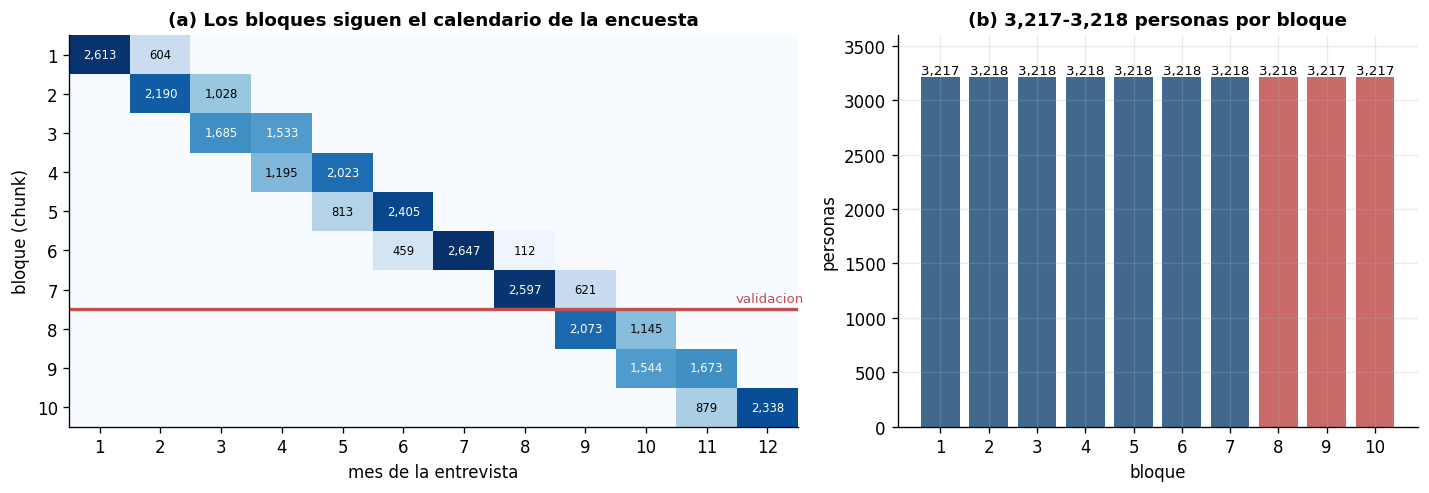

In [4]:
mb = apoyo["mes_por_bloque"]
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw={"width_ratios": [1.4, 1]})
im = ax[0].imshow(mb.to_numpy(), aspect="auto", cmap="Blues")
ax[0].set_xticks(range(mb.shape[1])); ax[0].set_xticklabels(mb.columns.astype(int)); ax[0].set_yticks(range(mb.shape[0])); ax[0].set_yticklabels(mb.index)
for i in range(mb.shape[0]):
    for j in range(mb.shape[1]):
        v = mb.iat[i, j]
        if v > 0: ax[0].text(j, i, f"{v:,}", ha="center", va="center", fontsize=7, color="white" if v > 1500 else "black")
ax[0].axhline(6.5, color=COL["va"], lw=2); ax[0].text(11.6, 6.4, "validacion", color=COL["va"], fontsize=8, ha="right", va="bottom")
ax[0].set_xlabel("mes de la entrevista"); ax[0].set_ylabel("bloque (chunk)"); ax[0].set_title("(a) Los bloques siguen el calendario de la encuesta"); ax[0].grid(False)
conteo = original["chunk"].value_counts().sort_index()
ax[1].bar(conteo.index, conteo.values, color=[COL["tr"] if c <= 7 else COL["va"] for c in conteo.index], alpha=0.85)
for k, v in conteo.items(): ax[1].text(k, v + 20, f"{v:,}", ha="center", fontsize=8)
ax[1].set_ylim(0, 3600); ax[1].set_xticks(conteo.index); ax[1].set_xlabel("bloque"); ax[1].set_ylabel("personas"); ax[1].set_title("(b) 3,217-3,218 personas por bloque")
plt.tight_layout(); plt.show()


### 2.1 Qué dicen las advertencias

Ninguna prueba dio error: las 32,177 filas, las 177 variables en el orden del sitio, las llaves, los códigos y todas las identidades entre variables construidas salen como se esperaba. Las cuatro advertencias son hechos de la fuente y valen como decisiones tomadas desde ya.

La primera es la partición temporal (panel a): cada bloque cubre dos o tres meses consecutivos, así que los bloques 1–7 son enero–septiembre y los bloques 8–10 son septiembre–diciembre. La validación de la Sección 3 mide la capacidad de predecir *hacia adelante en el año*, no una muestra aleatoria. La segunda es que `college` no es lo que dice el diccionario: vale 1 exactamente cuando el máximo nivel es secundaria completa, no terciaria; se reconstruye como `terciaria = (maxEducLevel == 7)`. La tercera es que el DANE reemplazó por imputación 20 ingresos observados que consideró extremos (`impaes` presente junto con `y_total_m`), que se marcan más abajo. La cuarta es que dos códigos de ocupación (20 y 78) solo aparecen en validación, que se asignan a Otros con una regla aprendida solo en entrenamiento.

## 3. De texto a números

La conversión es una operación única, `pd.to_numeric` sobre cada columna salvo `dominio`, y la validación ya comprobó que no crea ningún faltante adicional: los `"NA"` son los únicos faltantes y la notación científica solo aparece en cifras redondas de dos dígitos significativos (`7e+05` es exactamente 700,000). Lo que el catálogo del DANE aporta es la lectura de los códigos: en todos los montos el 98 significa "recibió pero no sabe el monto" y el 99 "no sabe si recibió"; en la antigüedad, 998 y 999; y el 9 solo es "no sabe" en algunas variables (`p6090`, `p6100`, `p6210`, las preguntas sí/no de ingresos), mientras que en `p6050`, `p6870` y `relab` es una categoría válida. La prueba 5.4 verificó que ninguno de esos códigos especiales sobrevive en los datos. El archivo `documentacion/verificacion_tipos_columnas.csv` cruza las 177 columnas con el tipo, el formato y las categorías que documenta el DANE, y recomienda el tipo en el análisis (numérica, dummy, factor).


In [5]:
tipado = gd.tipar(original)
tipado.to_csv(os.path.join(DATOS, "intermedios", "geih2018_tipado.csv"), index=False)
tipos = pd.read_csv(os.path.join(DATOS, "documentacion", "verificacion_tipos_columnas.csv"))
print("Tipos en la base tipada:", tipado[gd.VARIABLES_ESPERADAS].dtypes.astype(str).value_counts().to_dict())
print("Recomendación de tipo en el análisis (177 variables):")
print(tipos["tipo_recomendado_R"].str.split(" ").str[0].value_counts().to_dict())
tipos.loc[tipos["variable"].isin(["sex", "age", "relab", "oficio", "p6500", "p6750", "totalHoursWorked", "maxEducLevel", "college", "estrato1"]),
          ["variable", "variable_dane", "tipo_dane", "categorias_dane", "tipo_recomendado_R", "observaciones"]]


Tipos en la base tipada: {'float64': 158, 'int64': 18, 'object': 1}
Recomendación de tipo en el análisis (177 variables):
{'integer': 142, 'factor': 17, 'double': 16, 'integer;': 1, 'character': 1}
Out[5]: 
             variable variable_dane tipo_dane                                    categorias_dane                                 tipo_recomendado_R  \
6            estrato1     P4030S1A1  Discreta  0=Conexión pirata; 1=Bajo - bajo; 2=Bajo; 3=Me...                        factor (categórica; 9 = NA)   
7                 sex         P6020  Discreta                                  1=Hombre; 2=Mujer  integer 0/1 (DANE 1=hombre,2=mujer; curso 1=ho...   
8                 age         P6040  Continua                                                NaN                                 integer (continua)   
15             oficio        OFICIO  Discreta                                                NaN          factor (DANE: carácter 2 dígitos, CNO-70)   
17              relab         P6430  D

## 4. Limpieza: una sola muestra de análisis

Las decisiones, todas parametrizadas en `geih_datos.CONFIG`:

Población. Ocupados (`ocu == 1`) de 18 años o más, como exige el enunciado: 16,542 personas.

Ingreso. La variable de resultado es `y_total_m` (asalariados más independientes, mensual nominal de 2018) y la dependiente de los modelos es su logaritmo. De los ocupados de 18+, 1,778 no tienen `y_total_m`. No son personas sin ingreso: 248 son trabajadores sin remuneración (`relab` 6 y 7), que por definición no lo tienen; los otros 1,530 son asalariados con `p6500 = 0` e independientes con `p6750` vacío que trabajan jornada completa, tienen antigüedad, primas y formalidad, y simplemente no reportaron el monto. El propio DANE los clasifica como faltantes (`cclasnr2 = 1`) y les imputa `impaes`. Quedan fuera de la muestra principal , no hay logaritmo de un monto que no existe,  pero se conservan en una base ampliada con un `motivo_exclusion`, junto con `impaes` y `dane_faltante`, para análisis de robustez. No se imputa nada.

Extremos. No se recorta ni se winsoriza. Se crean banderas: ingreso por hora menor al 25 % del mínimo por hora de 2018 (≈ 950 pesos), ingreso mensual mayor a 20 salarios mínimos, más de 84 horas semanales, y los ingresos que el DANE reemplazó por imputación; `alerta_extremo` es su unión.

Categóricas. `relab`, educación, estrato, tamaño de firma, parentesco y régimen de salud (con la no respuesta como categoría) quedan con etiquetas. Los códigos de oficio con menos de 20 personas en entrenamiento, y los no observados allí, se asignan a "Otros". La frecuencia de validación no interviene en esta decisión; `relab` 8 y 9 (9 personas) se funden en "Otro". Se agregan variables derivadas económicamente relevantes: `female`, `jefe_hogar`, `terciaria`, `anios_educ` (años de escolaridad aproximados desde `p6210` y `p6210s1`, con la regla del DANE de que en educación superior se registran años completos), `antiguedad_anios`, `segundo_empleo`, `horas_segundo_empleo`, `quiere_mas_horas` (subempleo visible) y `cotiza_pension`.


In [6]:
L = gd.limpiar(tipado)
muestra, ocupados18 = L["muestra"], L["ocupados18"]
muestra.to_csv(os.path.join(DATOS, "limpios", "geih2018_muestra.csv"), index=False)
ocupados18.to_csv(os.path.join(DATOS, "limpios", "geih2018_ocupados18.csv"), index=False)
for nombre in ["embudo", "exclusiones", "alertas", "oficios", "diccionario"]:
    L[nombre].to_csv(os.path.join(DATOS, "auditoria", f"{nombre}_muestra.csv"), index=(nombre == "alertas"))
sin_doc = set(ocupados18.columns) - set(L["diccionario"]["variable"])
assert not sin_doc, f"variables sin documentar: {sin_doc}"
print("Muestra principal:", muestra.shape, "| Base ampliada:", ocupados18.shape)
print("Umbrales de alerta:", {k: round(v) for k, v in L["umbrales"].items()})
L["embudo"]


Muestra principal: (14764, 59) | Base ampliada: (16542, 61)
Umbrales de alerta: {'hora_bajo': 949, 'mensual_alto': 15624840}
Out[6]: 
   paso                                        descripcion  n_personas  n_excluidas
0     1                   Base tipada (todas las personas)       32177         <NA>
1     2                                Ocupados (ocu == 1)       16682        15495
2     3                    Ocupados de 18+ (base ampliada)       16542          140
3     4  Con ingreso laboral positivo observado (muestr...       14764         1778


Out[7]: 
                   n  alerta_ingreso_bajo  alerta_ingreso_alto  alerta_horas_altas  alerta_dane_extremo  alerta_extremo
muestra_ps3                                                                                                            
entrenamiento  10263                  185                   48                 155                   12             383
validacion      4501                   80                   25                  72                    8             172


<>:7: SyntaxWarning: invalid escape sequence '\('
<ipython-input-7-864949481fad>:7: SyntaxWarning: invalid escape sequence '\('
  ex = L["exclusiones"].copy(); ex["motivo"] = ex["motivo_exclusion"].str.split(" \(").str[0]


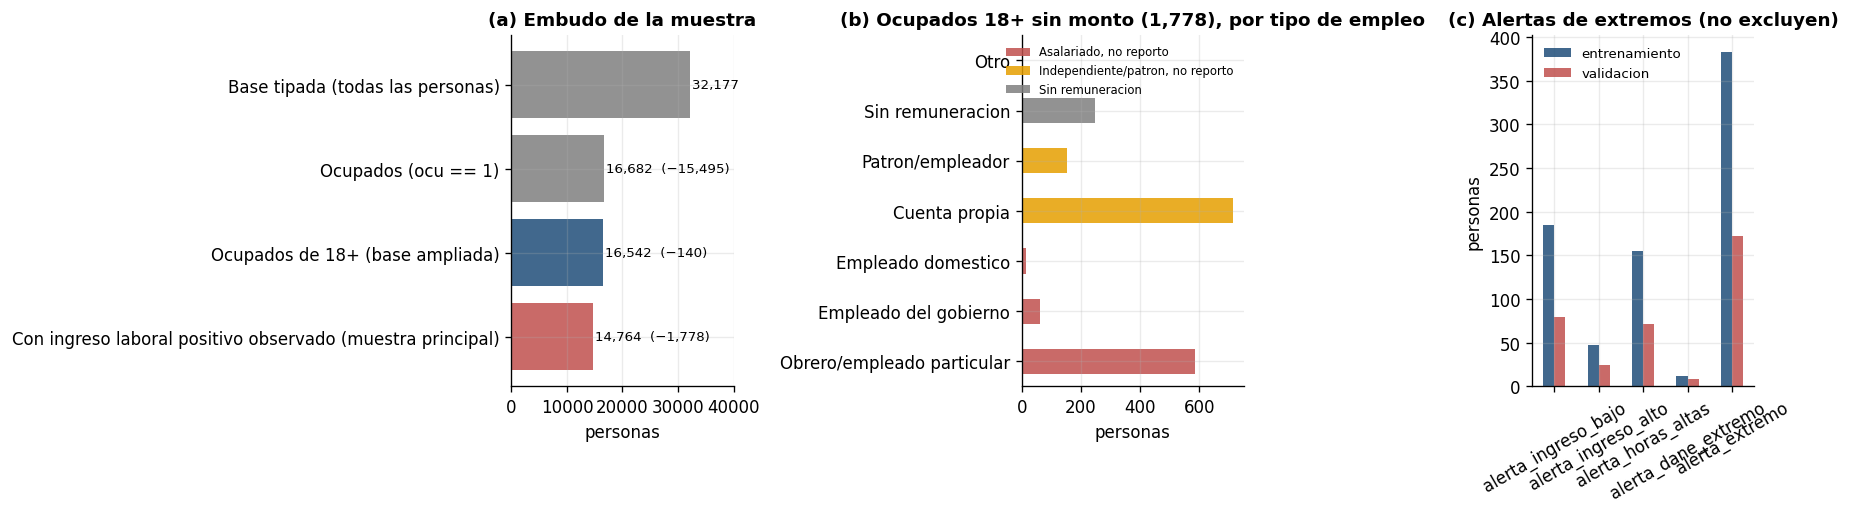

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))
e = L["embudo"]
ax[0].barh(e["descripcion"][::-1], e["n_personas"][::-1], color=[COL["gris"], COL["gris"], COL["tr"], COL["va"]][::-1], alpha=0.85)
for i, (n, ex) in enumerate(zip(e["n_personas"][::-1], e["n_excluidas"][::-1])):
    ax[0].text(n + 300, i, f"{n:,}" + (f"  (−{int(ex):,})" if pd.notna(ex) else ""), va="center", fontsize=8)
ax[0].set_xlim(0, 40000); ax[0].set_title("(a) Embudo de la muestra"); ax[0].set_xlabel("personas")
ex = L["exclusiones"].copy(); ex["motivo"] = ex["motivo_exclusion"].str.split(" \(").str[0]
piv = ex.pivot_table(index="relab_f", columns="motivo", values="n", aggfunc="sum", fill_value=0, observed=True)
piv.columns = [{"Asalariado que no reporto el monto": "Asalariado, no reporto", "Independiente o patron que no reporto el monto": "Independiente/patron, no reporto", "Sin remuneracion por definicion": "Sin remuneracion"}.get(c, c) for c in piv.columns]
piv.plot(kind="barh", stacked=True, ax=ax[1], color=[COL["va"], COL["acento"], COL["gris"]], alpha=0.85)
ax[1].set_title("(b) Ocupados 18+ sin monto (1,778), por tipo de empleo"); ax[1].set_xlabel("personas"); ax[1].set_ylabel("")
ax[1].legend(fontsize=7, loc="upper right")
al = L["alertas"].drop(columns=["n"]).T
al.plot(kind="bar", ax=ax[2], color=[COL["tr"], COL["va"]], alpha=0.85)
ax[2].set_title("(c) Alertas de extremos (no excluyen)"); ax[2].set_ylabel("personas"); ax[2].tick_params(axis="x", rotation=30); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()
L["alertas"]


## 5. Descriptivas ponderadas y soporte de la muestra

Las medias, distribuciones y proporciones siguientes usan `fex_c` para representar la población cubierta de Bogotá y no la distribución de filas. Los conteos del embudo, las validaciones de integridad, los n no nulos y sus porcentajes no se ponderan: miden registros disponibles y calidad de la base, no población. Los pesos no corrigen automáticamente la selección por no respuesta del ingreso.

### Personas representadas y precisión del total
Para el conjunto de registros $G$ utilizado en cada estimación se reportan dos cantidades distintas:
$$n_G=\sum_{i\in G}1,\qquad \widehat N_G=\sum_{i\in G}\texttt{fex\_c}_i.$$
$n_G$ cuenta observaciones y $\widehat N_G$ estima las personas representadas en la escala del archivo. Se suman los factores originales, sin normalizarlos a media uno. Los totales se presentan redondeados a personas; las tablas CSV conservan precisión completa. El total corresponde al grupo efectivamente incluido, no a todos los habitantes de Bogotá.

No se reporta IC del total poblacional: el archivo no suministra estratos de muestreo y unidades primarias identificados como tales, ni pesos replicados o información suficiente de calibración para estimar su varianza de diseño. `estrato1` es estrato socioeconómico y las llaves de hogar no sustituyen esa información. Un IC requeriría $\widehat N_G\pm1.96\widehat{EE}_{diseño}(\widehat N_G)$. La dispersión de los pesos o un bootstrap uniforme de su suma no recuperan por sí solos esa precisión. No disponible no significa incertidumbre cero. [Referencia sobre totales e inferencia de encuestas](https://search.r-project.org/CRAN/refmans/survey/html/surveysummary.html).

Los IC HC1 y bootstrap ya mostrados corresponden a medias, coeficientes o picos bajo la aproximación por personas descrita en el análisis; no son IC de $\widehat N_G$. Los grupos superpuestos y los modelos ajustados a las mismas personas no deben sumarse.

ambito,n_muestra,personas_representadas
Base completa,32177,8164164
Ocupados adultos,16542,4120583
Muestra de edad,14764,3686676
Muestra común de género y predicción,14763,3686406
"Entrenamiento, descriptivas",10263,2499677
"Validación, descriptivas",4501,1186999


Descriptivas (a), (b) y (c): 14,764 registros; aproximadamente 3,686,676 personas representadas por fex_c. IC del total: no disponible con el diseño suministrado.

Descriptiva de ingreso no observado (d): 16,542 registros; aproximadamente 4,120,583 personas representadas por fex_c. IC del total: no disponible con el diseño suministrado.

relab_f,media,sd,ee,n,poblacion,n_efectivo,IC_inf,IC_sup
Otro,12.4888,0.8754,0.3101,9,2054.5934,8.7715,11.8809,13.0967
Empleado domestico,13.2442,0.7264,0.0318,563,139256.0641,533.3382,13.1817,13.3066
Cuenta propia,13.4899,1.0314,0.0159,4391,1092990.2468,4171.9429,13.4588,13.5210
Obrero/empleado particular,14.0168,0.7262,0.0081,8757,2192799.5954,8246.3621,14.0011,14.0326
Patron/empleador,14.3261,0.8946,0.0430,473,120489.6108,444.3738,14.2419,14.4103
Empleado del gobierno,14.8136,0.5911,0.0251,571,139085.4452,549.4059,14.7644,14.8629


tramo,media,sd,ee,n,poblacion,n_efectivo,IC_inf,IC_sup
"(0, 12]",12.1673,1.1791,0.0559,455,110810.7352,434.5511,12.0577,12.2768
"(12, 20]",12.7805,1.0489,0.0496,467,116604.0531,440.2368,12.6834,12.8777
"(20, 30]",13.3582,1.0194,0.0364,812,199729.8614,769.4003,13.2869,13.4295
"(30, 40]",14.0437,1.0091,0.0230,2115,524551.7555,2003.8633,13.9987,14.0888
"(40, 48]",14.0187,0.6719,0.0084,6693,1659813.5141,6330.2363,14.0022,14.0352
"(48, 60]",13.9785,0.7831,0.0160,2537,643501.7618,2390.0177,13.9471,14.0099
"(60, 72]",13.8926,0.6897,0.0217,1084,275912.1587,1021.4116,13.8501,13.9351
"(72, 130]",13.9126,0.7171,0.0293,601,155751.7158,566.0398,13.8552,13.9701


relab_f,media,sd,ee,n,poblacion,n_efectivo,IC_inf,IC_sup
Empleado domestico,0.0264,0.1603,0.0069,578,143032.7498,547.8236,0.0130,0.0398
Obrero/empleado particular,0.0611,0.2396,0.0025,9342,2335553.0376,8800.4728,0.0562,0.0661
Empleado del gobierno,0.0973,0.2963,0.0123,632,154070.2865,604.9891,0.0731,0.1215
Otro,0.1172,0.3216,0.1151,10,2327.2675,9.7481,-0.1084,0.3427
Cuenta propia,0.1377,0.3445,0.0049,5106,1267464.4809,4859.5328,0.1281,0.1472
Patron/empleador,0.2327,0.4225,0.0170,626,157020.5674,590.4444,0.1993,0.2660
Sin remuneracion,1.0000,0.0000,0.0000,248,61114.2718,234.9728,1.0000,1.0000


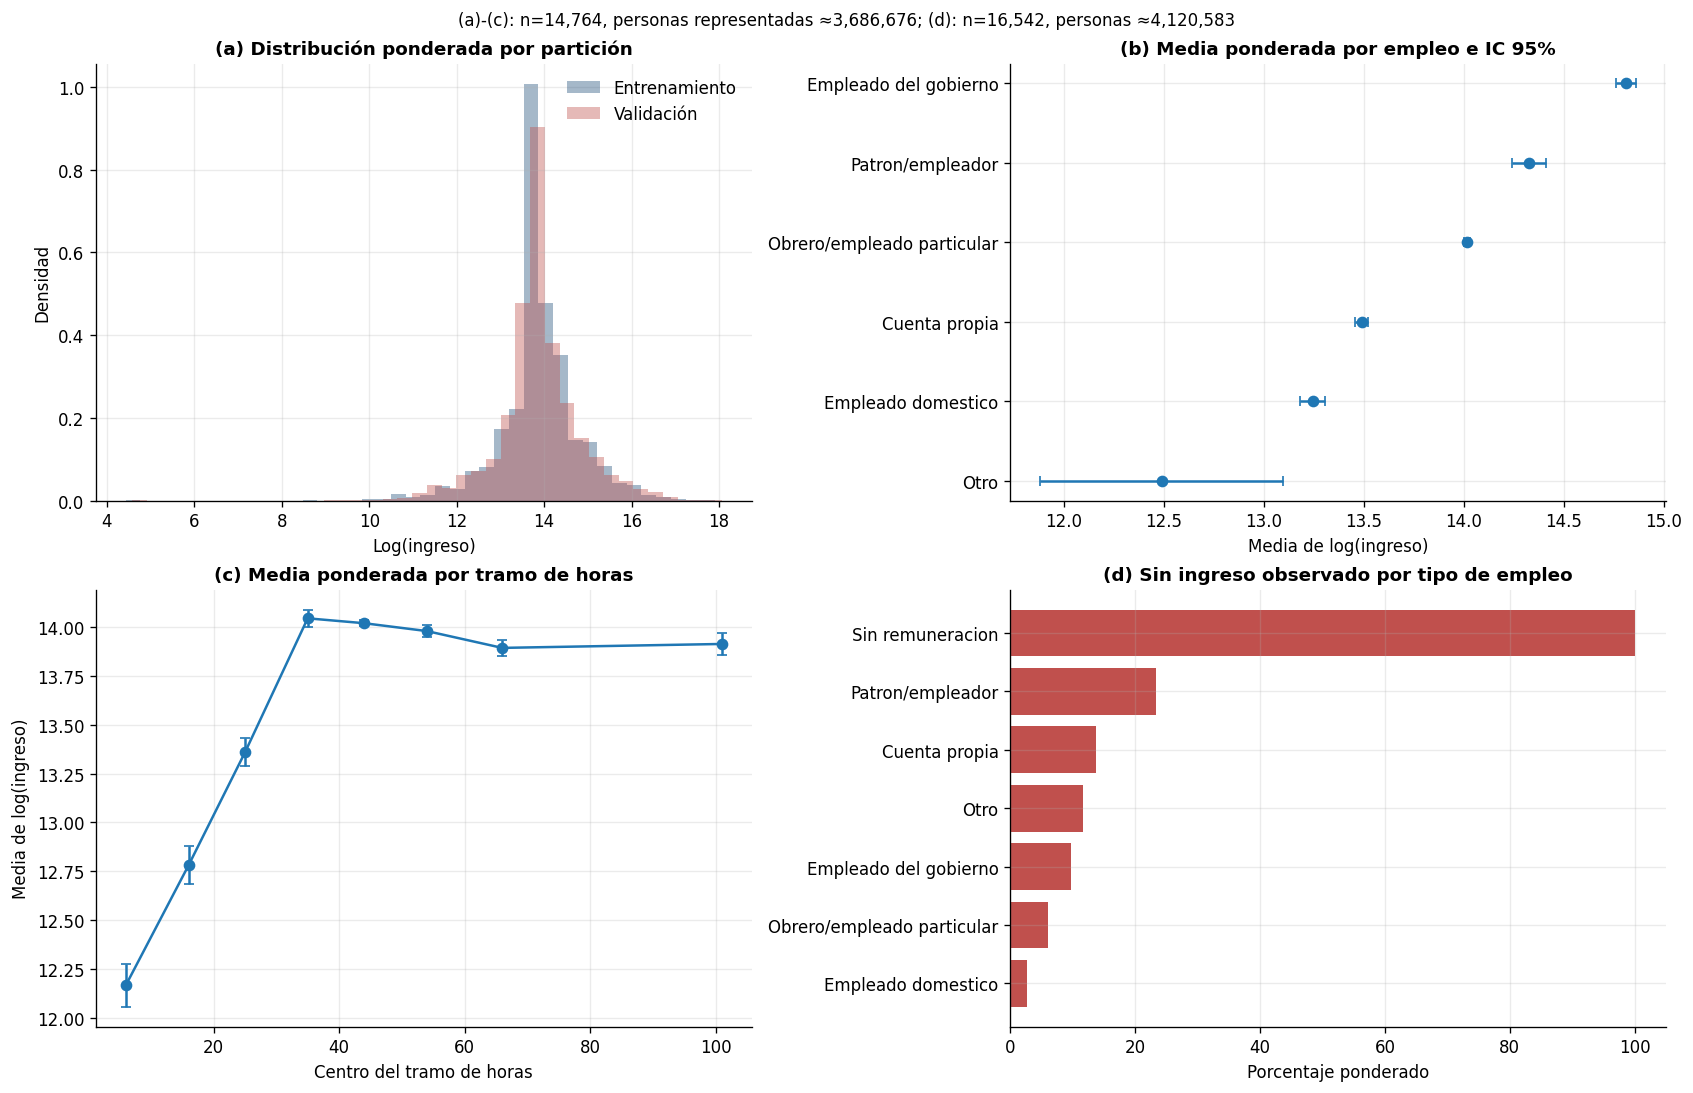

In [8]:
from src.reportes import tabla,por_grupo,resumen_variables,nota_poblacion,alcance,cobertura_grupos

ambitos=[('Base completa',tipado),('Ocupados adultos',ocupados18),('Muestra de edad',muestra),('Muestra común de género y predicción',muestra.loc[muestra.maxEducLevel.notna()]),('Entrenamiento, descriptivas',muestra.loc[muestra.entrenamiento]),('Validación, descriptivas',muestra.loc[~muestra.entrenamiento])]
tabla(pd.DataFrame([dict(ambito=nombre,**alcance(d)) for nombre,d in ambitos]),Path(DATOS)/'auditoria/poblacion_ambitos',decimales=0)
nota_poblacion(muestra,'Descriptivas (a), (b) y (c)')
nota_poblacion(ocupados18,'Descriptiva de ingreso no observado (d)')

fig,ax=plt.subplots(2,2,figsize=(14,9),layout='constrained')
for train,label,color in [(True,'Entrenamiento',COL['tr']),(False,'Validación',COL['va'])]:
    d=muestra[muestra.entrenamiento==train];ax[0,0].hist(d.log_y,bins=40,weights=d.fex_c,density=True,alpha=.4,color=color,label=label)
ax[0,0].set(title='(a) Distribución ponderada por partición',xlabel='Log(ingreso)',ylabel='Densidad');ax[0,0].legend()
g=por_grupo(muestra,'relab_f').sort_values('media')
tabla(g,Path(DATOS)/'auditoria/poblacion_y_media_empleo',plegable='Panel (b): n y personas representadas por empleo')
ax[0,1].errorbar(g.media,g.relab_f,xerr=1.96*g.ee,fmt='o',capsize=3);ax[0,1].set(title='(b) Media ponderada por empleo e IC 95%',xlabel='Media de log(ingreso)')
temp=muestra.assign(tramo=pd.cut(muestra.totalHoursWorked,[0,12,20,30,40,48,60,72,130]))
g=por_grupo(temp,'tramo')
tabla(g,Path(DATOS)/'auditoria/poblacion_y_media_horas',plegable='Panel (c): n y personas representadas por tramo de horas')
g['centro']=[x.mid for x in g.tramo]
ax[1,0].errorbar(g.centro,g.media,yerr=1.96*g.ee,fmt='o-',capsize=3);ax[1,0].set(title='(c) Media ponderada por tramo de horas',xlabel='Centro del tramo de horas',ylabel='Media de log(ingreso)')
o=ocupados18.assign(sin_ingreso=ocupados18.y_total_m.isna().astype(float))
g=por_grupo(o,'relab_f','sin_ingreso').sort_values('media')
tabla(g,Path(DATOS)/'auditoria/poblacion_y_no_respuesta',plegable='Panel (d): n y personas representadas, incluidos ingresos no observados')
ax[1,1].barh(g.relab_f,100*g.media,color=COL['va']);ax[1,1].set(title='(d) Sin ingreso observado por tipo de empleo',xlabel='Porcentaje ponderado')
fig.suptitle(f'(a)-(c): n={len(muestra):,}, personas representadas ≈{muestra.fex_c.sum():,.0f}; (d): n={len(ocupados18):,}, personas ≈{ocupados18.fex_c.sum():,.0f}',fontsize=10,fontweight='normal')
plt.show()

## 6. Variables disponibles para los análisis

La muestra principal conserva 14,764 registros. Género y predicción usan 14,763 al excluir un nivel educativo faltante de forma común entre especificaciones. `fex_c` se usa para descripción poblacional e inferencia ponderada; predicción explicita el criterio de pérdida sin ponderar del enunciado y muestra sensibilidad ponderada. Los campos monetarios que componen el resultado y las alertas construidas con él no son predictores admisibles.

In [9]:
L["diccionario"].assign(en_muestra_principal=lambda d: d["variable"].isin(muestra.columns))


Out[9]: 
               variable                                        descripcion      origen  en_muestra_principal
0            id_persona  Llave única de persona: directorio-secuencia_p...  construida                  True
1            directorio                           Llave de vivienda (GEIH)    original                  True
2           secuencia_p                                     Llave de hogar    original                  True
3                 orden                                   Llave de persona    original                  True
4                 chunk  Bloque del sitio (1-10); sigue el calendario d...   obtención                  True
..                  ...                                                ...         ...                   ...
56  alerta_ingreso_bajo    Ingreso por hora < fracción del mínimo por hora  construida                  True
57  alerta_ingreso_alto               Ingreso mensual > múltiplo del SMMLV  construida                  True
58   alert

## 7. Resumen de todas las variables
Se presentan todas las columnas de la base consolidada tipificada y todas las de la muestra de análisis. Para cada variable se registra tipo almacenado, número de no nulos, porcentaje de no nulos sobre el total de filas y número de valores distintos. Los resúmenes numéricos incluyen media, desviación estándar, mínimo, cuartiles y máximo; se conserva la moda para campos no numéricos.

Estos son resúmenes de integridad de la base sin `fex_c`: cada fila debe contar una vez para medir disponibilidad. Las medias de códigos nominales no tienen interpretación económica y aparecen solamente como descripción mecánica; el diccionario determina cuáles admiten lectura cuantitativa. Las tablas completas se exportan como CSV y LaTeX, sin truncar variables.

In [10]:
for nombre,df in [('base_completa',tipado),('muestra_analisis',muestra)]:
    resumen=resumen_variables(df)
    tabla(resumen,Path(DATOS)/'auditoria'/('summary_'+nombre),mostrar=False)
    display(Markdown('### '+nombre.replace('_',' ').capitalize()+f' ({len(df):,} filas, {len(df.columns)} variables)'))
    tabla(resumen[['variable','tipo','no_nulos','porcentaje_no_nulos','valores_distintos']],Path(DATOS)/'auditoria'/('cobertura_'+nombre),decimales=2)
    tabla(resumen[['variable','media','desv_est','minimo','p25','mediana','p75','maximo','moda']],Path(DATOS)/'auditoria'/('estadisticas_'+nombre),decimales=3)

### Base completa (32,177 filas, 181 variables)

variable,tipo,no_nulos,porcentaje_no_nulos,valores_distintos
fila_en_bloque,int64,32177,100.00,3218
directorio,int64,32177,100.00,10403
secuencia_p,int64,32177,100.00,4
orden,int64,32177,100.00,14
clase,int64,32177,100.00,1
dominio,object,32177,100.00,1
mes,int64,32177,100.00,12
estrato1,int64,32177,100.00,6
sex,int64,32177,100.00,2
age,int64,32177,100.00,102


variable,media,desv_est,minimo,p25,mediana,p75,maximo,moda
fila_en_bloque,1609.350,928.884,1.000,805.000,1609.000,2414.000,3218.000,1
directorio,4655586.722,82562.837,4514331.000,4584531.000,4655207.000,4728957.000,4804455.000,4753125
secuencia_p,1.013,0.126,1.000,1.000,1.000,1.000,4.000,1
orden,2.411,1.434,1.000,1.000,2.000,3.000,14.000,1
clase,1.000,0.000,1.000,1.000,1.000,1.000,1.000,1
dominio,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BOGOTA
mes,6.405,3.399,1.000,3.000,6.000,9.000,12.000,6
estrato1,2.519,1.005,1.000,2.000,2.000,3.000,6.000,2
sex,0.479,0.500,0.000,0.000,0.000,1.000,1.000,0
age,34.399,20.881,0.000,18.000,32.000,50.000,106.000,23


### Muestra analisis (14,764 filas, 59 variables)

variable,tipo,no_nulos,porcentaje_no_nulos,valores_distintos
id_persona,object,14764,100.00,14764
directorio,int64,14764,100.00,8689
secuencia_p,int64,14764,100.00,4
orden,int64,14764,100.00,12
chunk,int64,14764,100.00,10
muestra_ps3,object,14764,100.00,2
entrenamiento,bool,14764,100.00,2
mes,int64,14764,100.00,12
mes_f,category,14764,100.00,12
fex_c,float64,14764,100.00,3320


variable,media,desv_est,minimo,p25,mediana,p75,maximo,moda
id_persona,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4514331-1-1
directorio,4657875.275,81694.197,4514331.000,4588557.750,4655331.000,4728991.250,4804455.000,4564479
secuencia_p,1.015,0.136,1.000,1.000,1.000,1.000,4.000,1
orden,1.917,1.219,1.000,1.000,2.000,2.000,12.000,1
chunk,5.576,2.844,1.000,3.000,6.000,8.000,10.000,6
muestra_ps3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,entrenamiento
entrenamiento,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
mes,6.497,3.362,1.000,4.000,6.000,9.000,12.000,5
mes_f,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5
fex_c,249.707,60.239,106.613,215.010,240.748,270.184,808.241,227.510631909004
